# Federated normative modeling

In multi-site neuroimaging studies, data often cannot leave the hospital or institution where it was collected, due to privacy regulations such as GDPR. **Federated learning (FL)** addresses this constraint: each site trains a model locally and shares only the trained model; never the raw data.

This tutorial demonstrates a FL workflow for normative modeling using the PCNtoolkit. For more details you can read the paper below:

> Kia SM, Huijsdens H, Rutherford S, de Boer A, Dinga R, Wolfers T, et al. (2022)  
> *Closing the life-cycle of normative modeling using federated hierarchical Bayesian regression.*  
> PLoS ONE 17(12): e0278776. https://doi.org/10.1371/journal.pone.0278776

### What we will do

**Classic normative modelling workflow**
1. *Fit a model* on all data together (let's call it *baseline model* as later we will compare it with the aggregated model produced from the FL workflow)

**Prepare the data for FL**

2. *Split* the data into a large central dataset and two smaller ones
3. *Fit a central model* on the central dataset only

**FL with `extend()`**

4. *Extend* the central model to each of the two smaller datasets
5. *Merge (= aggregate)* the central model and the two extended models into a single global model
6. *Evaluate* final aggregated model 

**FL with `transfer()`**

7. *Transfer* the central model to each of the two smaller datasets
7. *Merge* the central model and the two transferred models into a single global model
6. *Evaluate* final aggregated model 

**Evaluation**

10. *Compare* the aggregated models to the baseline model

### The functions that we will use

| Function | Role |
|---|---|
| `NormativeModel.fit()` | Fit the central model |
| `NormativeModel.extend()` | Refit the central model with data from the smaller model + synthetic data (generated from the central model) |
| `NormativeModel.transfer()` | Transfer the central model's priors to the smaller dataset |
| `NormativeModel.merge()` | Merge (= aggregate) central + extended/transferred models |
| `NormativeModel.predict()` | Evaluate the final aggregated model |

### Imports

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormalLikelihood,
    NormativeModel,
    NormData,
    load_fcon1000,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
)

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

## Load data

We use the [fcon1000](https://fcon_1000.projects.nitrc.org/fcpClassic/FcpTable.html) dataset that is included in PCNtoolkit, which contains resting state fMRI from 1078 subjects across 23 sites. We select a single response variable (`WM-hypointensities`) to keep the tutorial fast.

In [2]:
# Download the dataset
norm_data: NormData = load_fcon1000()

# Select only the white matter hypointensities feature
features_to_model = ["WM-hypointensities"]
norm_data = norm_data.sel(
    {"response_vars": features_to_model}
)

# Show all available sites
all_sites = np.unique(
    norm_data.batch_effects.sel(
        batch_effect_dims="site"
    ).values
)
print(
    f"Total sites: {len(all_sites)}"
)
print(f"Sites: {all_sites}")

Total sites: 23
Sites: ['AnnArbor_a' 'AnnArbor_b' 'Atlanta' 'Baltimore' 'Bangor' 'Beijing_Zang'
 'Berlin_Margulies' 'Cambridge_Buckner' 'Cleveland' 'ICBM' 'Leiden_2180'
 'Leiden_2200' 'Milwaukee_b' 'Munchen' 'NewYork_a' 'NewYork_a_ADHD'
 'Newark' 'Oulu' 'Oxford' 'PaloAlto' 'Pittsburgh' 'Queensland'
 'SaintLouis']


## Split data

We split the data into:
- A large central dataset (19 sites)
- Two smaller datasets (each dataset has 2 sites) 

In a FL scenario the large model would be owned by a central location (e.g., a hospital in the Netherlands) and the smaller ones by remote locations 1 and 2 (e.g, a hospital in France and in the USA). All these locations don't want to share their data due to privacy. For this reason, they use the FL workflow.

![alt text](resources\federated_learning\fl-graph.png)

Figure 1: Adopted from Fed-BioMed toolbox (for more info see: https://fedbiomed.org/)

In [3]:
# Pick 2 sites for each remote location
location1_sites = list(all_sites[:2])
location2_sites = list(all_sites[2:4])
print(
    f"Location 1 sites: {location1_sites}"
)
print(
    f"Location 2 sites: {location2_sites}"
)

# Split off location 1
location1_data, remaining = (
    norm_data.batch_effects_split(
        {"site": location1_sites},
        names=("location1", "remaining"),
    )
)

# Split off location 2 
location2_data, central_data = (
    remaining.batch_effects_split(
        {"site": location2_sites},
        names=("location2", "central"),
    )
)

# Create train/test splits for each location
train_central, test_central = (
    central_data.train_test_split()
)
train_location1, test_location1 = (
    location1_data.train_test_split()
)
train_location2, test_location2 = (
    location2_data.train_test_split()
)

# Global train/test for the baseline model
train_all, test_all = (
    norm_data.train_test_split()
)

print(
    f"\nCentral: "
    f"{train_central.X.shape[0]} train, "
    f"{test_central.X.shape[0]} test"
)
print(
    f"Location 1: "
    f"{train_location1.X.shape[0]} train, "
    f"{test_location1.X.shape[0]} test"
)
print(
    f"Location 2: "
    f"{train_location2.X.shape[0]} train, "
    f"{test_location2.X.shape[0]} test"
)
print(
    f"All data: "
    f"{train_all.X.shape[0]} train, "
    f"{test_all.X.shape[0]} test"
)

Location 1 sites: [np.str_('AnnArbor_a'), np.str_('AnnArbor_b')]
Location 2 sites: [np.str_('Atlanta'), np.str_('Baltimore')]

Central: 776 train, 195 test
Location 1: 44 train, 12 test
Location 2: 40 train, 11 test
All data: 862 train, 216 test


## Visualize the data

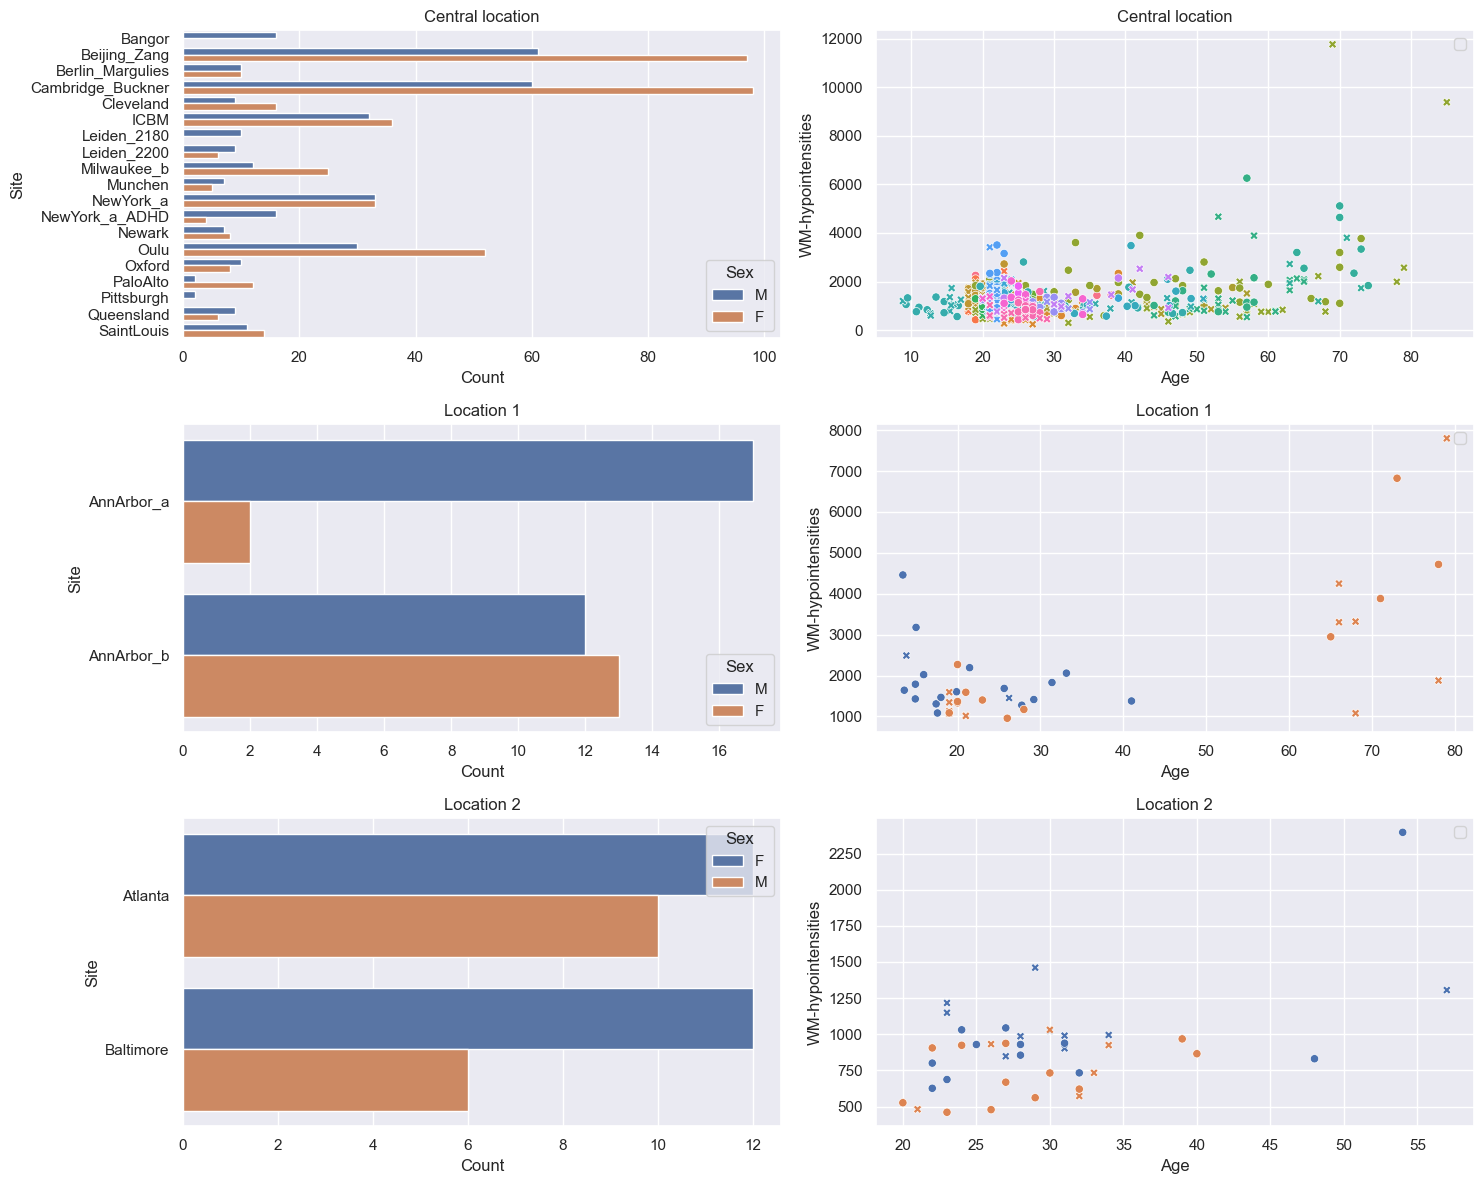

In [4]:
feature = features_to_model[0]
datasets = {
    "Central location": train_central,
    "Location 1": train_location1,
    "Location 2": train_location2,
}

fig, axes = plt.subplots(
    3, 2, figsize=(15, 12)
)

# for every dataset
for i, (name, data) in enumerate(
    datasets.items()
):
    df = data.to_dataframe()
    # Count plot
    sns.countplot(
        data=df,
        y=("batch_effects", "site"),
        hue=("batch_effects", "sex"),
        ax=axes[i, 0],
        orient="h",
    )
    axes[i, 0].legend(title="Sex")
    axes[i, 0].set_title(
        f"{name}"
    )
    axes[i, 0].set_xlabel("Count")
    axes[i, 0].set_ylabel("Site")

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=("X", "age"),
        y=("Y", feature),
        hue=("batch_effects", "site"),
        style=("batch_effects", "sex"),
        ax=axes[i, 1],
    )
    axes[i, 1].legend([], [])
    axes[i, 1].set_title(
        f"{name}"
    )
    axes[i, 1].set_xlabel("Age")
    axes[i, 1].set_ylabel(feature)

plt.tight_layout()
plt.show()

## Configure the HBR model

We define a shared model configuration that will be used for **all** models (baseline, central, transferred, and aggregated). This ensures a fair comparison. We use a Normal likelihood HBR with B-spline basis functions.

For a detailed explanation of this configuration, see *Tutorial 03 - HBR with Normal Likelihood*.

In [5]:
# Prior for the mean function (mu)
mu = make_prior(
    linear=True,
    slope=make_prior(
        dist_name="Normal",
        dist_params=(0.0, 5.0),
    ),
    intercept=make_prior(
        random=True,
        mu=make_prior(
            dist_name="Normal",
            dist_params=(0.0, 1.0),
        ),
        sigma=make_prior(
            dist_name="Gamma",
            dist_params=(1.0, 1.0),
        ),
    ),
    basis_function=BsplineBasisFunction(
        basis_column=0, nknots=5, degree=3
    ),
)

# Prior for the noise function (sigma)
sigma = make_prior(
    linear=True,
    slope=make_prior(
        dist_name="Normal",
        dist_params=(0.0, 2.0),
    ),
    intercept=make_prior(
        dist_name="Normal",
        dist_params=(1.0, 1.0),
    ),
    basis_function=BsplineBasisFunction(
        basis_column=0, nknots=5, degree=3
    ),
    mapping="softplus",
    mapping_params=(0.0, 2.0),
)

likelihood = NormalLikelihood(mu, sigma)

template_hbr = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=likelihood,
)

---

## Part 1: Baseline model

In a non-FL scenario, we would pool all the data from every site into a single dataset and train one model.

In [39]:
baseline_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=False,
    save_dir=(
        "resources/federated/baseline"
    ),
    inscaler="standardize",
    outscaler="standardize",
);

baseline_model.fit_predict(
    train_all, test_all);

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,13,0.13,255
,2000,4,0.12,31
,2000,61,0.12,95
,2000,10,0.12,63


---

## Part 2: FL with `extend()`

Now we simulate the FL scenario. The central location **does not have access** to the data at Location 1 and Location 2. Only model parameters are exchanged.

### Step 1: Train the central model

The central location trains an HBR model using only its own 19 sites.

In [10]:
central_model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=False,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir=(
        "resources/federated/central"
    ),
    inscaler="standardize",
    outscaler="standardize",
)

central_model.fit(train_central)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,6,0.12,63
,2000,6,0.12,31
,2000,14,0.12,127
,2000,19,0.14,31


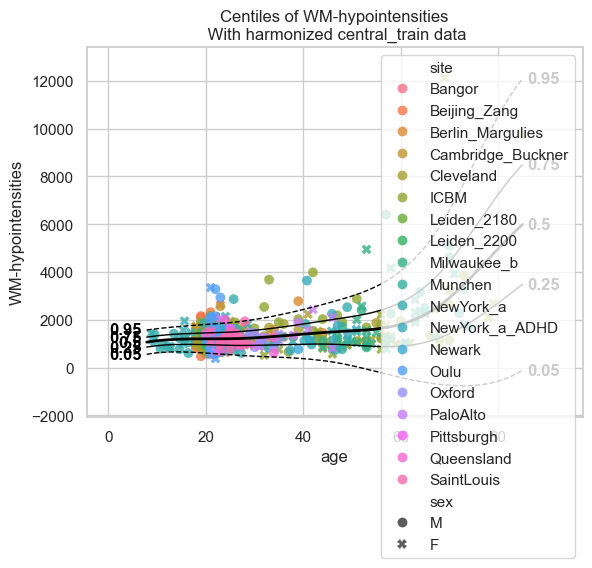

In [43]:
# Centile curves for the central model
plot_centiles_advanced(
    central_model,
    scatter_data=train_central,
    batch_effects="all",
)

### Step 2: Extend the central model to remote locations

Each remote location receives the central model file and calls `extend()` locally using its own private data.

`extend()` synthesizes data from the central model's learned distribution, merges it with the real local data, and refits a full model.

**No real data is exchanged only model parameters.**

In [57]:
# Location 1 extends the central model
# with their private data.
extended_1 = central_model.extend(
    train_location1,
    save_dir=(
        "resources/federated/extended_1"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,13,0.12,63
,2000,7,0.10,255
,2000,4,0.11,255
,2000,18,0.11,31


In [55]:
# Location 2 extends the central model
# with their private data.
extended_2 = central_model.extend(
    train_location2,
    save_dir=(
        "resources/federated/extended_2"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,27,0.11,191
,2000,14,0.11,95
,2000,4,0.11,191
,2000,15,0.12,127


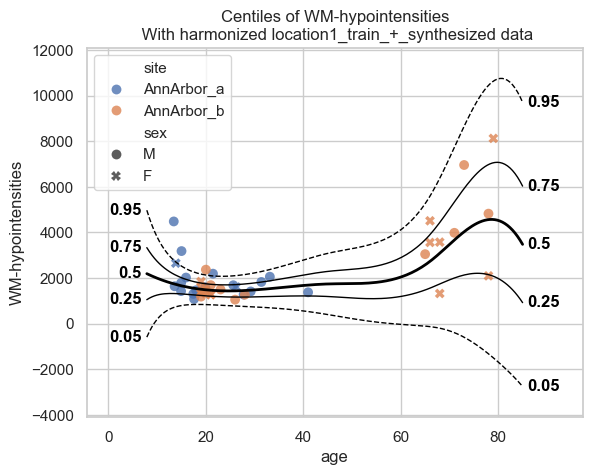

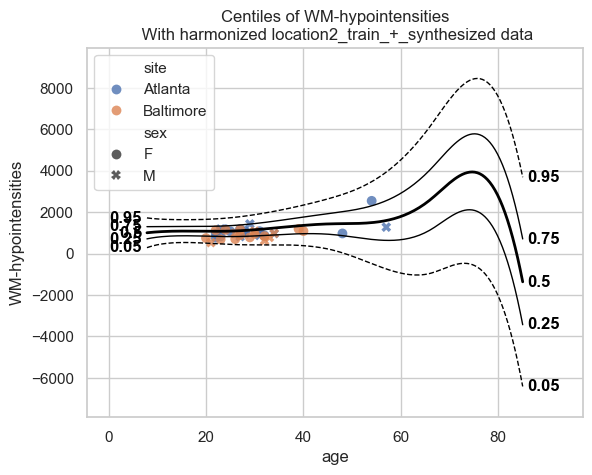

In [14]:
# Visualize the extended models
plot_centiles_advanced(
    extended_1,
    scatter_data=train_location1,
    batch_effects="all",
)

plot_centiles_advanced(
    extended_2,
    scatter_data=train_location2,
    batch_effects="all",
)

Each extended model knows about both the central sites (via synthetic data) and its own local sites.

### Step 3: Merge extended models

Merge the central model with both extended models using `NormativeModel.merge()`.

Under the hood, `merge()` does the following:
1. Calls `synthesize()` on each model to generate synthetic data from its learned distribution
2. Pools all synthetic datasets together
3. Refits a single global model on the combined synthetic data

**No real data is exchanged only model parameters.**

In [15]:
# Merge central + both extended models
aggregated_model_with_extend = NormativeModel.merge(
    save_dir=(
        "resources/federated/merged_extend"
    ),
    models=[
        central_model,
        extended_1,
        extended_2,
    ],
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,29,0.11,63
,2000,13,0.13,127
,2000,9,0.12,127
,2000,34,0.12,31


### Step 4: Predict with the aggregated model

The aggregated model now covers all 23 sites. We can predict on the full test set.

In [16]:
# make a copy that holds all the test data
test_all_extended = test_all.copy(deep=True)
# Predict the test data based on the aggegated model
aggregated_model_with_extend.predict(
    test_all_extended
);

---

## Part 3: FL with `transfer()`

We now repeat the federated workflow, but using `transfer()` instead of `extend()`.

### Step 1: Transfer to both locations

In [22]:
# Location 1 transfers the central model
transferred_1 = central_model.transfer(
    train_location1,
    save_dir=(
        "resources/federated/transferred_1"
    ),
)

# Location 2 transfers the central model
transferred_2 = central_model.transfer(
    train_location2,
    save_dir=(
        "resources/federated/transferred_2"
    ),
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,1,0.29,15
,2000,0,0.28,15
,2000,0,0.30,15
,2000,1,0.29,15


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.22,63
,2000,0,0.22,31
,2000,2,0.21,31
,2000,1,0.20,31


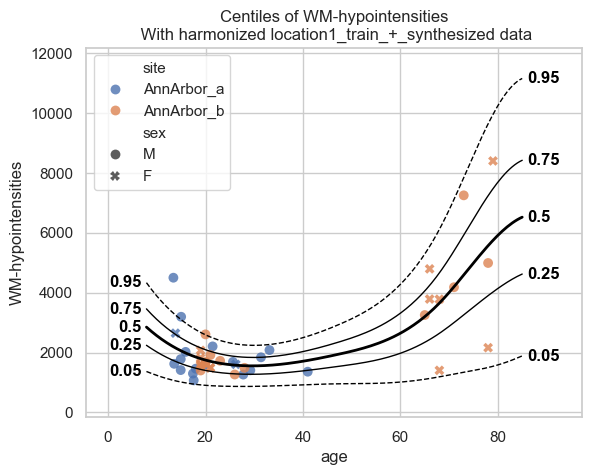

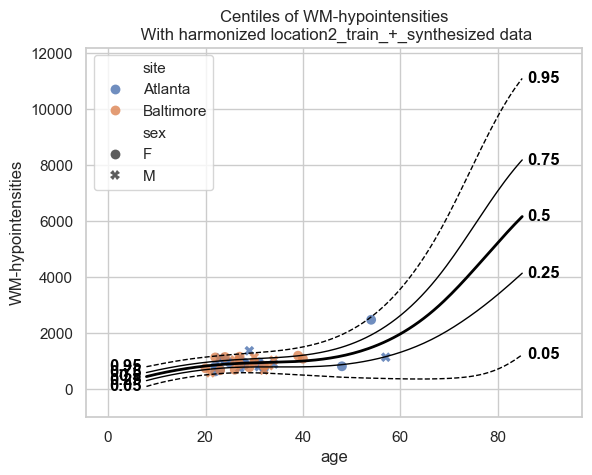

In [29]:
# Visualize the transferred models
plot_centiles_advanced(
    transferred_1,
    scatter_data=train_location1,
    batch_effects="all",
)

plot_centiles_advanced(
    transferred_2,
    scatter_data=train_location2,
    batch_effects="all",
)

### Step 2: Merge transferred models and predict

In [23]:
# Merge central + both transferred models
aggregated_model_with_transfer = NormativeModel.merge(
    save_dir="resources/federated/merged_transfer",
    models=[
        central_model,
        transferred_1,
        transferred_2,
    ],
)

# Predict on the full test set
test_all_transferred = test_all.copy(deep=True)
aggregated_model_with_transfer.predict(test_all_transferred);

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,115,0.12,63
,2000,23,0.13,63
,2000,16,0.12,63
,2000,17,0.12,31


---

## Final comparison: aggregated (extend) vs aggregated (transfer) vs. baseline

We now compare all three models:
- **baseline**: all data pooled 
- **Aggregated (extend)**: remote sites used `extend()` 
- **Aggregated (transfer)**: remote sites used `transfer()` 

### Centile curves

=== baseline model ===


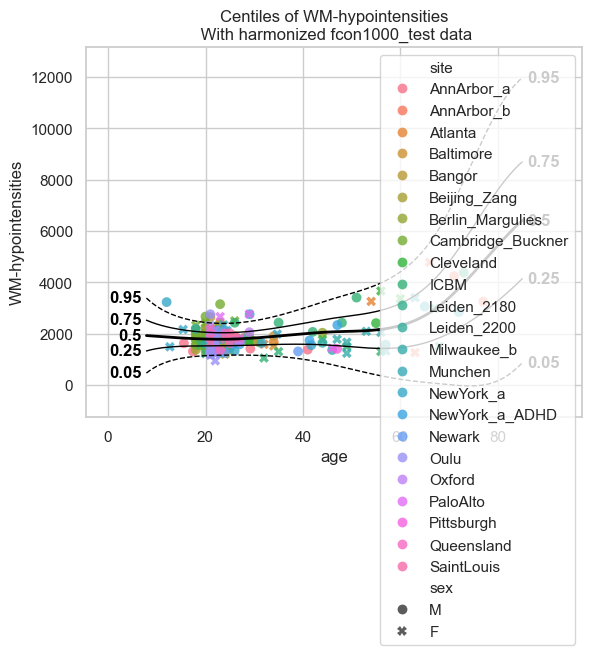


=== Aggregated (extend) ===


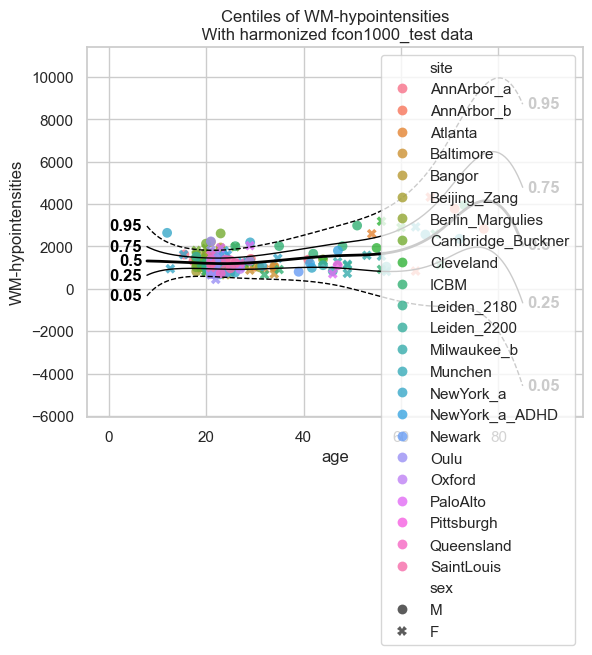


=== Aggregated (transfer) ===


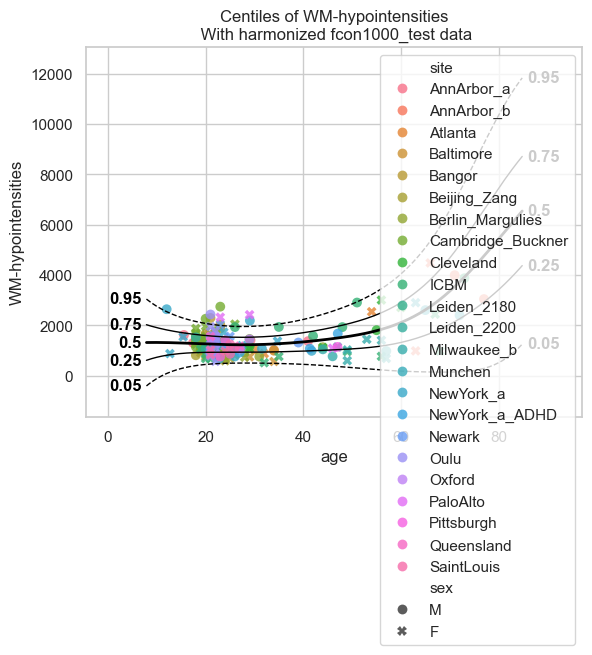

In [44]:
# baseline model centiles
print("=== baseline model ===")
plot_centiles_advanced(
    baseline_model,
    scatter_data=test_all,
    batch_effects="all",
)

# Aggregated model centiles (extend)
print("\n=== Aggregated (extend) ===")
plot_centiles_advanced(
    aggregated_model_with_extend,
    scatter_data=test_all,
    batch_effects="all",
)

# Aggregated model centiles (transfer)
print("\n=== Aggregated (transfer) ===")
plot_centiles_advanced(
    aggregated_model_with_transfer,
    scatter_data=test_all,
    batch_effects="all",
)

### QQ plots and evaluation metrics

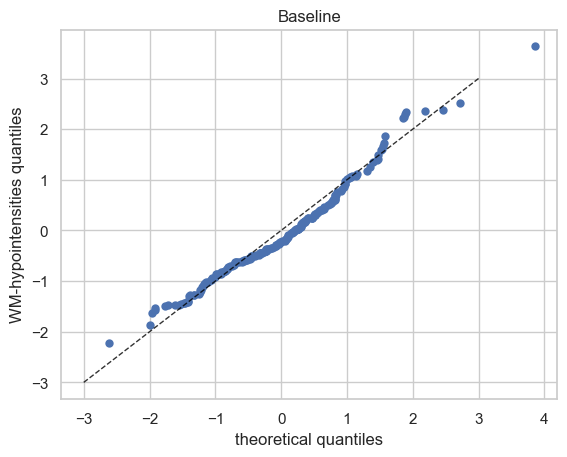

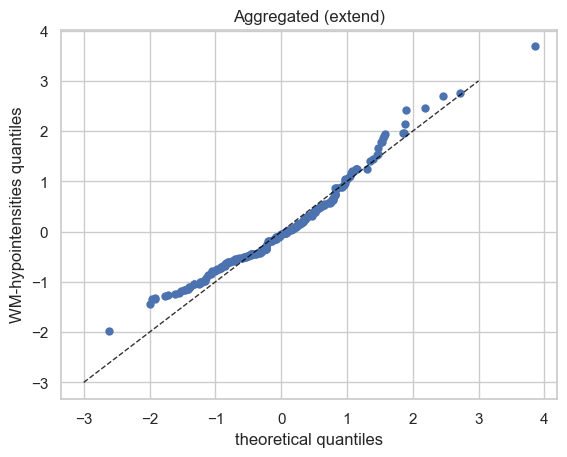

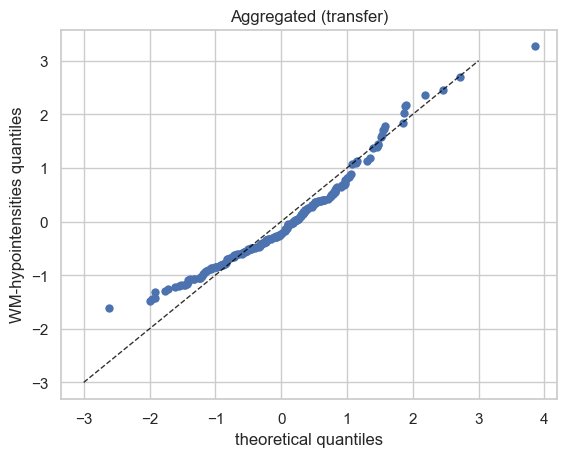

,statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
,response_vars,,,,,,,,,,,
baseline,WM-hypointensities,0.364491,0.037963,0.341857,-0.325236,0.794033,0.361229,483.720431,0.491288,1.593487e-14,0.638771,0.964110
Aggregated (extend),WM-hypointensities,0.375230,0.038889,0.325758,-0.332533,0.852269,0.375080,478.447034,0.486297,3.195466e-14,0.624920,0.953946
Aggregated (transfer),WM-hypointensities,0.301542,0.045370,0.373265,-0.262187,0.922615,0.297489,507.280598,0.399070,1.159051e-09,0.702511,0.947188


In [26]:
# QQ plots for all three models
plt.title("Baseline")
plot_qq(test_all, plot_id_line=True)

plt.title("Aggregated (extend)")
plot_qq(
    test_all_extended, plot_id_line=True
)

plt.title("Aggregated (transfer)")
plot_qq(
    test_all_transferred, plot_id_line=True
)

# Evaluation metrics for all three
baseline_stats = (
    test_all.get_statistics_df()
)
extend_stats = (
    test_all_extended.get_statistics_df()
)
transfer_stats = (
    test_all_transferred.get_statistics_df()
)

comparison = pd.concat(
    [
        baseline_stats,
        extend_stats,
        transfer_stats,
    ]
    , keys=[
        "baseline",
        "Aggregated (extend)",
        "Aggregated (transfer)",
    ]
)
comparison

## Conclusions

### Centile plots

Looking at the centile plots, both aggregated models fit the test
data well across most of the age range. 

The **aggregated (extend)** model shows an abrupt divergence at
old ages (> 70 years). This happens because `extend()` fits a model on synthetic 
data from the central model and real local data. The synthetic and the real local 
data have almost no datapoints beyond age ~70 . 
As a result the model does not fit well for these ages.


### QQ plots

Both aggregated models show a systematic deviation from the
identity line at the **lower tail** of the QQ plot. That means the
model "expects" the lowest-percentile subjects to have smaller
observed values than they actually do.

# Post-hoc


## extend: before merge()


Location 1:
  Synthetic points (age > 70): 208
  Real local points (age > 70): 5
  Synth Y range at old ages: [-6459, 12434]
  Synth Y std at old ages: 3087
  Real Y range at old ages: [1879, 7799]
  Synth-to-real ratio at old ages: 41.6x

Location 2:
  Synthetic points (age > 70): 208
  Real local points (age > 70): 0
  Synth Y range at old ages: [-6459, 12434]
  Synth Y std at old ages: 3087
  Real Y range at old ages: NO real data above 70!
  Synth-to-real ratio at old ages: ∞ (no real old-age data)


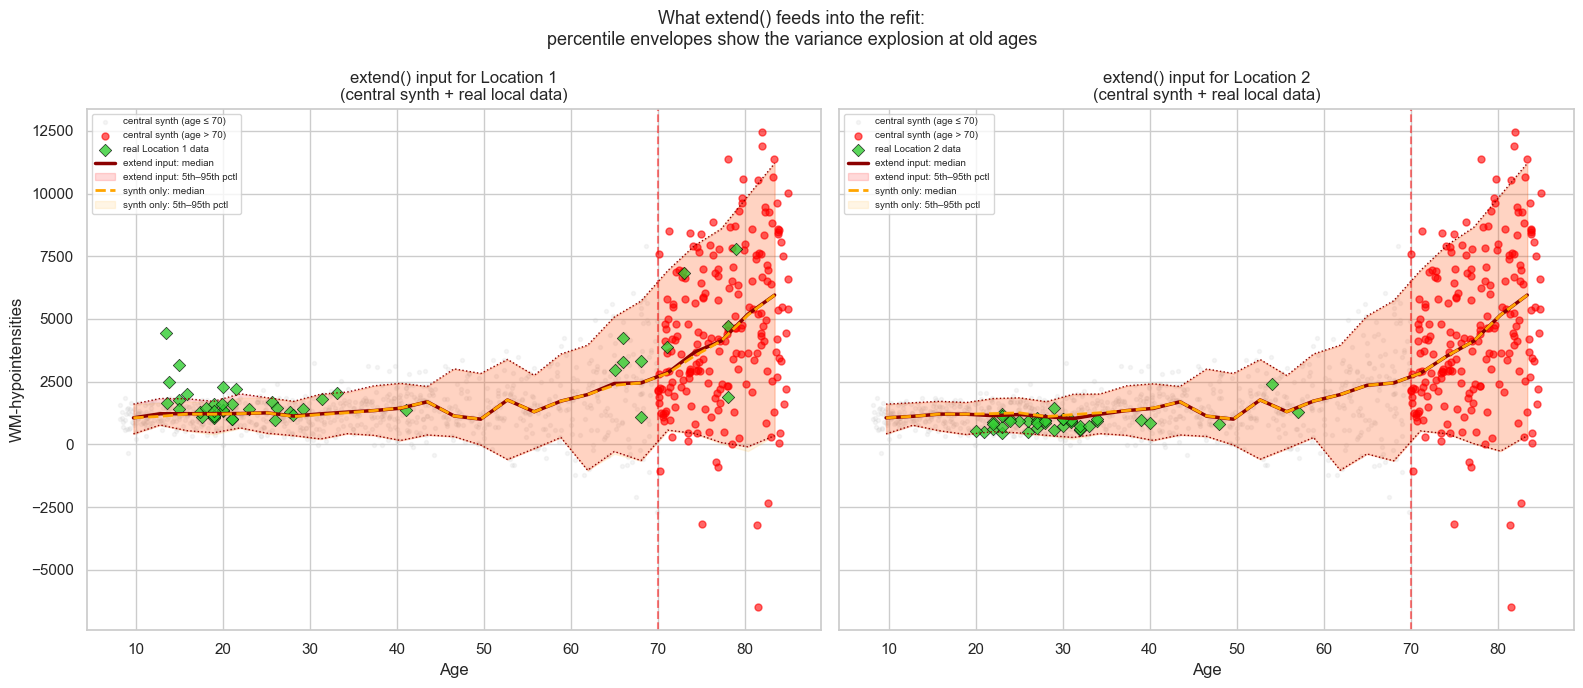

In [53]:
# Reproduce the data that extend() feeds into its
# refit: central_model.synthesize() + real local
# data. This is the dataset the extended model
# trains on.
# Instead of mean trend lines, we plot percentile
# envelopes (5th / 95th) in rolling age bins —
# this mirrors what centile plots show and makes
# the variance explosion at old ages visible.

# Generate synthetic data exactly as extend() does
central_synth = central_model.synthesize(
    
)

# Extract ages and Y from the synthetic data
synth_ages_c = central_synth.X.sel(
    covariates="age"
).values
synth_y_c = central_synth.Y.sel(
    response_vars=features_to_model[0]
).values

# Real local data for location 1 and location 2
local_datasets = {
    "Location 1": train_location1,
    "Location 2": train_location2,
}


def rolling_percentiles(
    x, y, n_bins=30, pcts=(5, 50, 95),
):
    """Compute percentiles of y in rolling
    age bins.

    Parameters
    ----------
    x : np.ndarray
        Age values.
    y : np.ndarray
        Response values.
    n_bins : int
        Number of equally spaced bins.
    pcts : tuple of int
        Percentiles to compute.

    Returns
    -------
    bin_centers : np.ndarray
        Center of each bin.
    result : dict
        Mapping from percentile to array.
    """
    # Create equally-spaced bin edges
    edges = np.linspace(
        x.min(), x.max(), n_bins + 1
    )
    # Compute the center of each bin
    centers = 0.5 * (edges[:-1] + edges[1:])
    result = {p: [] for p in pcts}
    valid = []
    for i in range(n_bins):
        # Select points within this bin
        mask = (x >= edges[i]) & (
            x < edges[i + 1]
        )
        # Include rightmost edge in last bin
        if i == n_bins - 1:
            mask = mask | (x == edges[i + 1])
        if mask.sum() >= 2:
            for p in pcts:
                result[p].append(
                    np.percentile(y[mask], p)
                )
            valid.append(i)
    # Convert to arrays, keep only valid bins
    bin_centers = centers[valid]
    result = {
        p: np.array(v)
        for p, v in result.items()
    }
    return bin_centers, result


fig, axes = plt.subplots(
    1, 2, figsize=(16, 7), sharey=True
)

for ax, (loc_name, local_data) in zip(
    axes, local_datasets.items()
):
    # ── Synthetic data from central model ─────
    old_synth = synth_ages_c > AGE_THRESHOLD
    young_synth = ~old_synth

    # Plot young-age synthetic (grey)
    ax.scatter(
        synth_ages_c[young_synth],
        synth_y_c[young_synth],
        alpha=0.15, s=8, color="silver",
        label=(
            f"central synth "
            f"(age \u2264 {AGE_THRESHOLD})"
        ),
        zorder=1,
    )

    # Plot old-age synthetic highlighted (red)
    ax.scatter(
        synth_ages_c[old_synth],
        synth_y_c[old_synth],
        alpha=0.6, s=25, color="red",
        label=(
            f"central synth "
            f"(age > {AGE_THRESHOLD})"
        ),
        zorder=3,
    )

    # ── Real local data overlaid ──────────────
    real_ages_loc = local_data.X.sel(
        covariates="age"
    ).values
    real_y_loc = local_data.Y.sel(
        response_vars=features_to_model[0]
    ).values

    ax.scatter(
        real_ages_loc, real_y_loc,
        alpha=0.8, s=40, marker="D",
        color="limegreen", edgecolors="black",
        linewidths=0.5,
        label=f"real {loc_name} data",
        zorder=4,
    )

    # ── Percentile envelopes ─────────────────
    # 1) Combined (synth + real) — what
    #    extend() actually trains on
    combined_x = np.concatenate(
        [synth_ages_c, real_ages_loc]
    )
    combined_y = np.concatenate(
        [synth_y_c, real_y_loc]
    )
    # Compute 5th, 50th, 95th percentiles
    bc, pcts_c = rolling_percentiles(
        combined_x, combined_y, n_bins=25
    )
    # Plot the median as a solid line
    ax.plot(
        bc, pcts_c[50],
        color="darkred", lw=2.5, ls="-",
        label="extend input: median",
        zorder=5,
    )
    # Fill between 5th and 95th
    ax.fill_between(
        bc, pcts_c[5], pcts_c[95],
        color="red", alpha=0.15,
        label="extend input: 5th–95th pctl",
        zorder=2,
    )
    # Plot the 5th and 95th lines
    ax.plot(
        bc, pcts_c[5],
        color="darkred", lw=1, ls=":",
        zorder=5,
    )
    ax.plot(
        bc, pcts_c[95],
        color="darkred", lw=1, ls=":",
        zorder=5,
    )

    # 2) Synth-only envelope — central model's
    #    generative behaviour
    bc_s, pcts_s = rolling_percentiles(
        synth_ages_c, synth_y_c, n_bins=25
    )
    ax.plot(
        bc_s, pcts_s[50],
        color="orange", lw=2, ls="--",
        label="synth only: median",
        zorder=5,
    )
    ax.fill_between(
        bc_s, pcts_s[5], pcts_s[95],
        color="orange", alpha=0.10,
        label="synth only: 5th–95th pctl",
        zorder=2,
    )

    # ── Threshold line ────────────────────────
    ax.axvline(
        AGE_THRESHOLD, color="red",
        ls="--", alpha=0.5, lw=1.5,
    )
    ax.set_xlabel("Age")
    ax.set_title(
        f"extend() input for {loc_name}\n"
        f"(central synth + real local data)"
    )
    ax.legend(fontsize=7, loc="upper left")

    # Print stats comparing synthetic vs real
    # at old ages
    n_synth_old = old_synth.sum()
    old_real_loc = real_ages_loc > AGE_THRESHOLD
    n_real_old = old_real_loc.sum()
    print(
        f"\n{loc_name}:"
    )
    print(
        f"  Synthetic points (age > "
        f"{AGE_THRESHOLD}): {n_synth_old}"
    )
    print(
        f"  Real local points (age > "
        f"{AGE_THRESHOLD}): {n_real_old}"
    )
    if n_synth_old > 0:
        print(
            f"  Synth Y range at old ages: "
            f"[{synth_y_c[old_synth].min():.0f}"
            f", {synth_y_c[old_synth].max():.0f}]"
        )
        print(
            f"  Synth Y std at old ages: "
            f"{synth_y_c[old_synth].std():.0f}"
        )
    if n_real_old > 0:
        print(
            f"  Real Y range at old ages: "
            f"[{real_y_loc[old_real_loc].min():.0f}"
            f", {real_y_loc[old_real_loc].max():.0f}]"
        )
    else:
        print(
            f"  Real Y range at old ages: "
            f"NO real data above {AGE_THRESHOLD}!"
        )
    # Ratio: how much synthetic overwhelms real
    if n_real_old > 0:
        ratio = n_synth_old / n_real_old
        print(
            f"  Synth-to-real ratio at old ages: "
            f"{ratio:.1f}x"
        )
    else:
        print(
            f"  Synth-to-real ratio at old ages: "
            f"\u221e (no real old-age data)"
        )

axes[0].set_ylabel(features_to_model[0])

plt.suptitle(
    "What extend() feeds into the refit:\n"
    "percentile envelopes show the variance "
    "explosion at old ages",
    fontsize=13,
)
plt.tight_layout()
plt.show()


## extend + transfer: after merge()

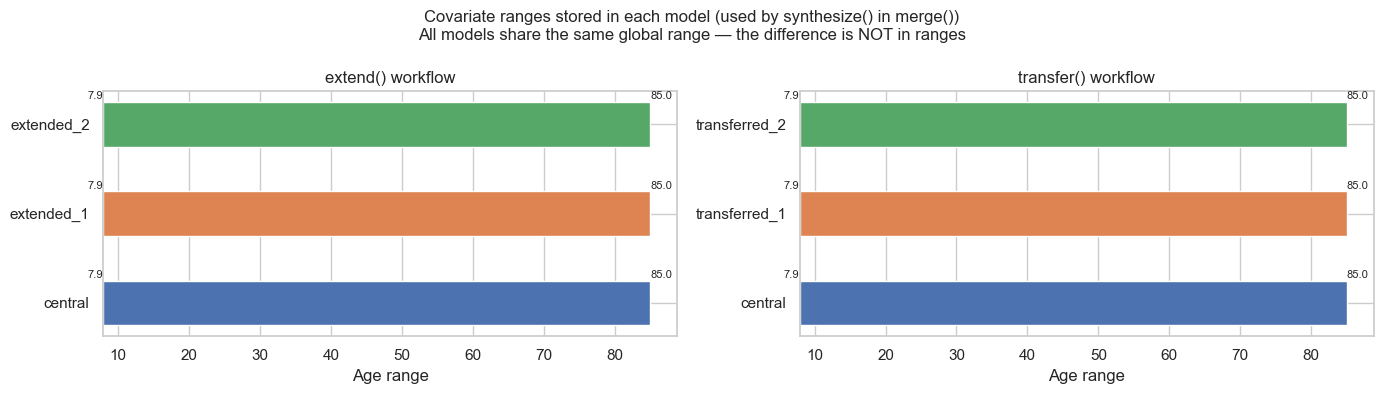

extend() | central: 19 remote-site synth points with age > 70 | Y std = 3718.5
extend() | extended_1: 18 remote-site synth points with age > 70 | Y std = 2854.4
extend() | extended_2: 27 remote-site synth points with age > 70 | Y std = 2548.3
transfer() | central: 14 remote-site synth points with age > 70 | Y std = 3477.7
transfer() | transferred_1: 13 remote-site synth points with age > 70 | Y std = 2355.7
transfer() | transferred_2: 33 remote-site synth points with age > 70 | Y std = 2242.7


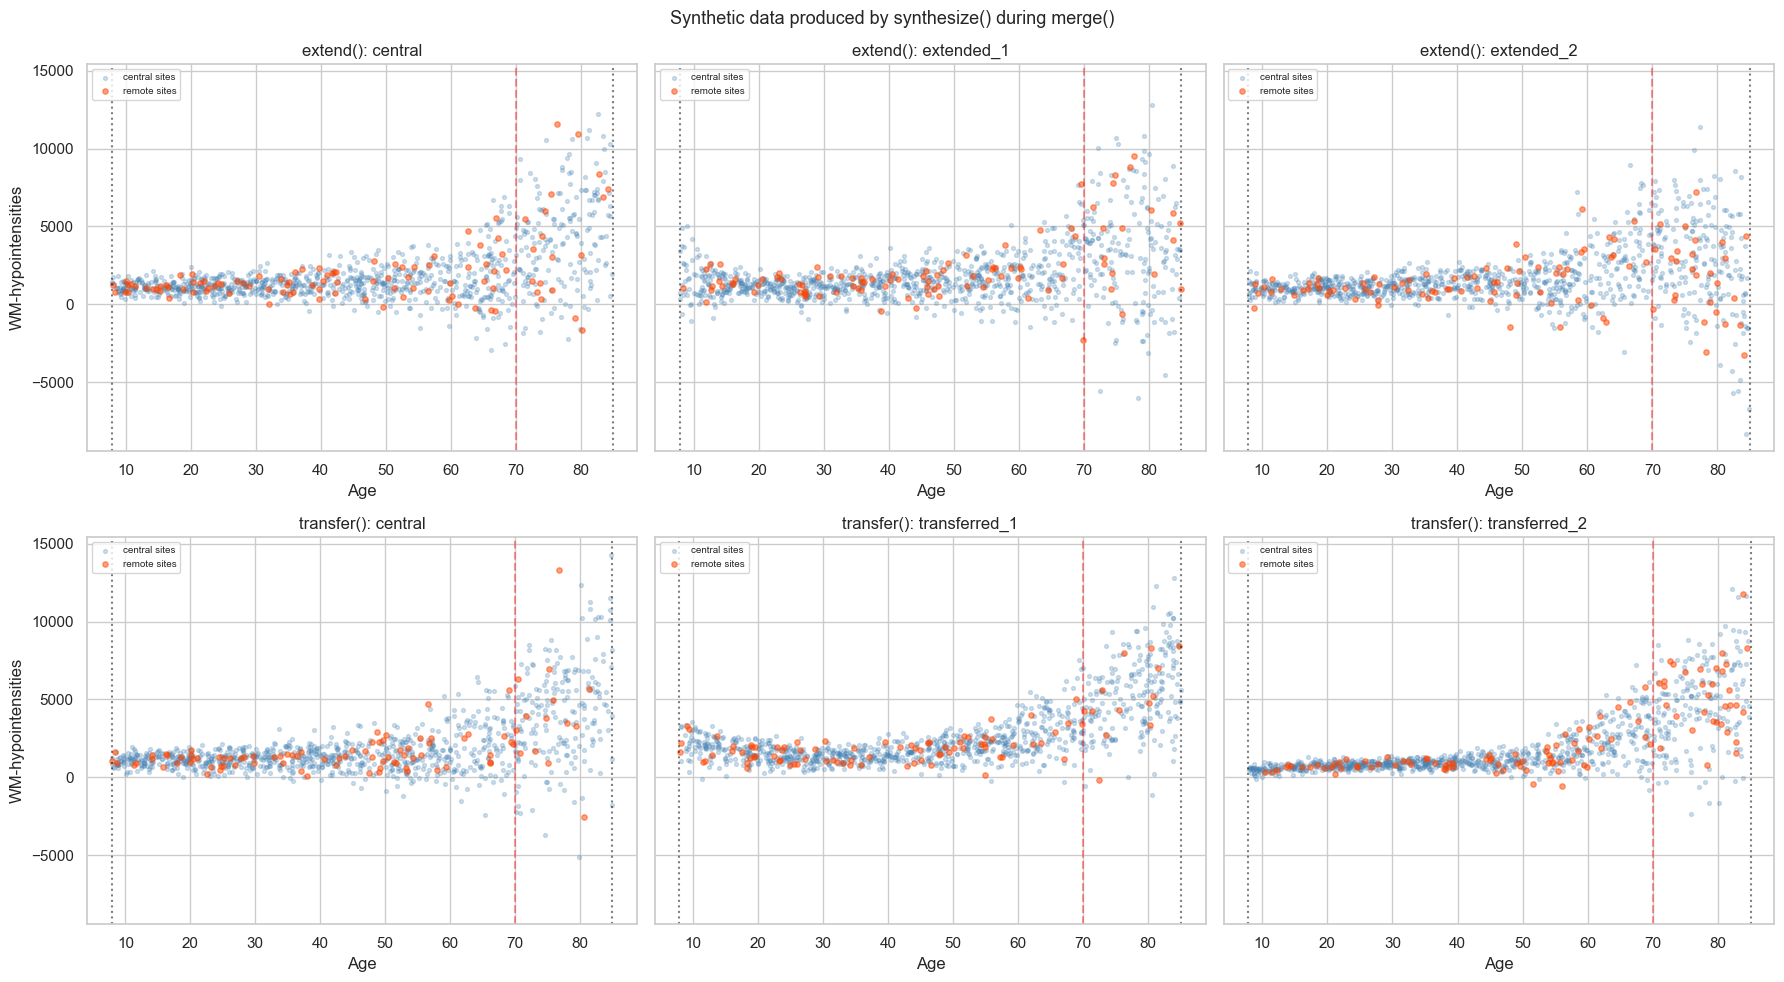


=== Centile spread comparison at old ages ===
This shows how each model's learned parameters behave at old ages.
Extended models already have distorted centiles before merge.
  extended_1: std(Y | age>70) = 3210.9 (n=199)
  extended_2: std(Y | age>70) = 3067.7 (n=210)
  transferred_1: std(Y | age>70) = 2697.2 (n=186)
  transferred_2: std(Y | age>70) = 2531.2 (n=216)


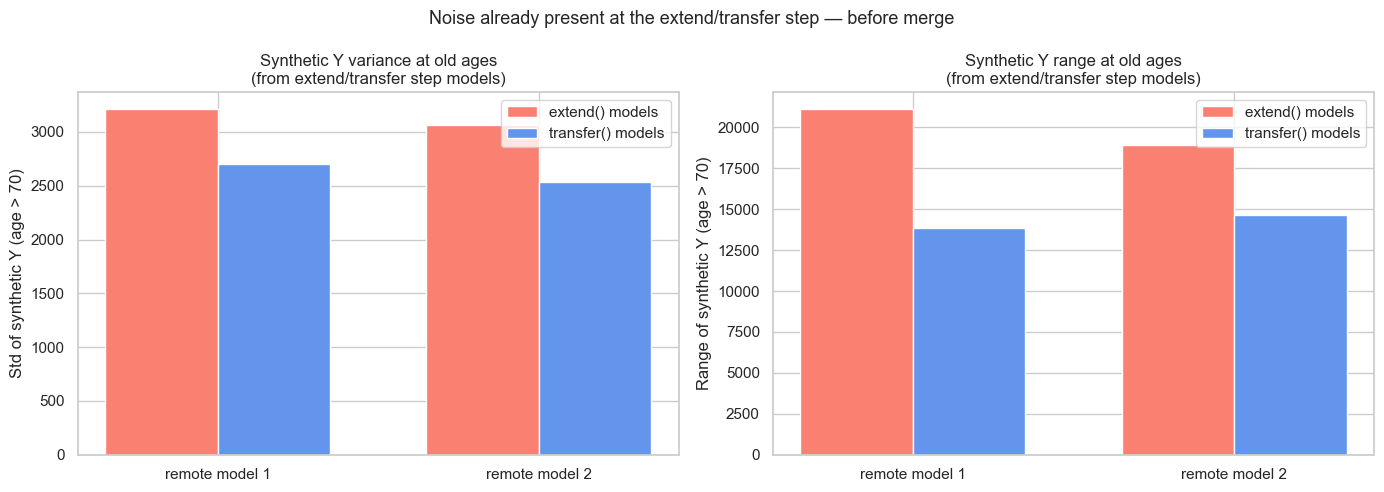

In [54]:
# Compare covariate ranges and synthetic data
# between extend() and transfer() workflows

# ── 1. Covariate-range comparison ──────────────
extend_models = {
    "central": central_model,
    "extended_1": extended_1,
    "extended_2": extended_2,
}
transfer_models = {
    "central": central_model,
    "transferred_1": transferred_1,
    "transferred_2": transferred_2,
}

fig, axes = plt.subplots(
    1, 2, figsize=(14, 4)
)

for ax, (title, models) in zip(
    axes,
    [
        ("extend() workflow", extend_models),
        ("transfer() workflow", transfer_models),
    ],
):
    for i, (name, m) in enumerate(
        models.items()
    ):
        lo = m.covariate_ranges["age"]["min"]
        hi = m.covariate_ranges["age"]["max"]
        ax.barh(
            i, hi - lo, left=lo,
            height=0.5, label=name
        )
        ax.text(
            lo, i + 0.28,
            f"{lo:.1f}",
            fontsize=8, ha="right",
        )
        ax.text(
            hi, i + 0.28,
            f"{hi:.1f}",
            fontsize=8, ha="left",
        )
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(list(models.keys()))
    ax.set_xlabel("Age range")
    ax.set_title(title)

plt.suptitle(
    "Covariate ranges stored in each model"
    " (used by synthesize() in merge())\n"
    "All models share the same global range"
    " — the difference is NOT in ranges",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# ── 2. Synthetic-data side-by-side ────────────
fig, axes = plt.subplots(
    2, 3, figsize=(18, 10), sharey=True
)

# Collect old-age variance stats
old_age_stats = {}

for row, (wf_title, models) in enumerate(
    [
        ("extend()", extend_models),
        ("transfer()", transfer_models),
    ]
):
    for col, (name, model) in enumerate(
        models.items()
    ):
        ax = axes[row, col]
        # Synthesize as merge() would
        synth = model.synthesize()
        synth_ages = synth.X.sel(
            covariates="age"
        ).values
        synth_y = synth.Y.sel(
            response_vars=features_to_model[0]
        ).values

        # Separate by batch-effect site
        synth_sites = synth.batch_effects.sel(
            batch_effect_dims="site"
        ).values

        # Color central sites blue,
        # remote sites orange/red
        central_sites_set = set(
            central_data.batch_effects.sel(
                batch_effect_dims="site"
            ).values
        )
        is_central = np.array(
            [s in central_sites_set
             for s in synth_sites]
        )
        ax.scatter(
            synth_ages[is_central],
            synth_y[is_central],
            alpha=0.25, s=8, color="steelblue",
            label="central sites",
        )
        ax.scatter(
            synth_ages[~is_central],
            synth_y[~is_central],
            alpha=0.5, s=15, color="orangered",
            label="remote sites",
        )

        # Mark the old-age threshold
        ax.axvline(
            AGE_THRESHOLD, color="red",
            ls="--", alpha=0.4,
        )

        # Show the model's stored age range
        lo = model.covariate_ranges["age"]["min"]
        hi = model.covariate_ranges["age"]["max"]
        ax.axvline(
            lo, color="black",
            ls=":", alpha=0.5,
        )
        ax.axvline(
            hi, color="black",
            ls=":", alpha=0.5,
        )

        ax.set_title(f"{wf_title}: {name}")
        ax.set_xlabel("Age")
        if col == 0:
            ax.set_ylabel(features_to_model[0])
        ax.legend(fontsize=7, loc="upper left")

        # Compute old-age remote-site stats
        old_remote = (
            (~is_central)
            & (synth_ages > AGE_THRESHOLD)
        )
        n_remote_old = old_remote.sum()
        key = f"{wf_title} | {name}"
        if n_remote_old > 0:
            old_age_stats[key] = {
                "n": int(n_remote_old),
                "y_std": float(
                    synth_y[old_remote].std()
                ),
                "y_mean": float(
                    synth_y[old_remote].mean()
                ),
            }
        else:
            old_age_stats[key] = {
                "n": 0,
                "y_std": 0.0,
                "y_mean": 0.0,
            }

        print(
            f"{key}: "
            f"{n_remote_old} remote-site "
            f"synth points with age "
            f"> {AGE_THRESHOLD}"
            f" | Y std = "
            f"{old_age_stats[key]['y_std']:.1f}"
        )

plt.suptitle(
    "Synthetic data produced by synthesize()"
    " during merge()",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# ── 3. Compare centile spread at old ages ─────
# This shows the damage already present at the
# extend/transfer step BEFORE merge
print(
    "\n=== Centile spread comparison "
    "at old ages ==="
)
print(
    "This shows how each model's learned"
    " parameters behave at old ages."
)
print(
    "Extended models already have distorted"
    " centiles before merge."
)

# Generate predictions at old ages to measure
# the centile spread (0.95 - 0.05) for each
# remote model
from pcntoolkit.dataio.norm_data import (
    NormData as ND,
)

step_models = {
    "extended_1": extended_1,
    "extended_2": extended_2,
    "transferred_1": transferred_1,
    "transferred_2": transferred_2,
}

# For each model, synthesize and look at the
# spread of Y at old ages across all batch
# effects
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5)
)

# Left: std of synthetic Y at old ages
# (all batch effects, not just remote)
model_names = []
ext_all_stds = []
tr_all_stds = []

for name, model in step_models.items():
    synth = model.synthesize()
    ages_s = synth.X.sel(
        covariates="age"
    ).values
    y_s = synth.Y.sel(
        response_vars=features_to_model[0]
    ).values
    old = ages_s > AGE_THRESHOLD
    if old.sum() > 0:
        std_val = float(y_s[old].std())
    else:
        std_val = 0.0

    if "extended" in name:
        ext_all_stds.append(std_val)
    else:
        tr_all_stds.append(std_val)

    print(
        f"  {name}: std(Y | age>{AGE_THRESHOLD})"
        f" = {std_val:.1f}"
        f" (n={old.sum()})"
    )

# Bar chart comparing stds
x = np.arange(2)
width = 0.35
labels = ["remote model 1", "remote model 2"]
axes[0].bar(
    x - width / 2, ext_all_stds, width,
    label="extend() models", color="salmon",
)
axes[0].bar(
    x + width / 2, tr_all_stds, width,
    label="transfer() models",
    color="cornflowerblue",
)
axes[0].set_ylabel(
    f"Std of synthetic Y (age > {AGE_THRESHOLD})"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].set_title(
    "Synthetic Y variance at old ages\n"
    "(from extend/transfer step models)"
)

# Right: Y range (max - min) at old ages
ext_ranges = []
tr_ranges = []
for name, model in step_models.items():
    synth = model.synthesize()
    ages_s = synth.X.sel(
        covariates="age"
    ).values
    y_s = synth.Y.sel(
        response_vars=features_to_model[0]
    ).values
    old = ages_s > AGE_THRESHOLD
    if old.sum() > 0:
        rng = float(
            y_s[old].max() - y_s[old].min()
        )
    else:
        rng = 0.0
    if "extended" in name:
        ext_ranges.append(rng)
    else:
        tr_ranges.append(rng)

axes[1].bar(
    x - width / 2, ext_ranges, width,
    label="extend() models", color="salmon",
)
axes[1].bar(
    x + width / 2, tr_ranges, width,
    label="transfer() models",
    color="cornflowerblue",
)
axes[1].set_ylabel(
    f"Range of synthetic Y (age > {AGE_THRESHOLD})"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()
axes[1].set_title(
    "Synthetic Y range at old ages\n"
    "(from extend/transfer step models)"
)

plt.suptitle(
    "Noise already present at the "
    "extend/transfer step — before merge",
    fontsize=13,
)
plt.tight_layout()
plt.show()